In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

#### adding:  dpLCI + pGWP-fixedCO2

## plot 

In [3]:
df_full = pd.read_excel("plot_rankshift_hydro_ei_reservoir.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])


In [4]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

metric_labels = {m: m for m in metric_order}
metric_labels

{'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP',
 'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',
 'staticLCI + pGWP-fixedCO2': 'staticLCI + pGWP-fixedCO2',
 'dyn-FG-LCI + pGWP-fixedCO2': 'dyn-FG-LCI + pGWP-fixedCO2',
 'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2'}

#### plot on year, two regions 

(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-19'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP1-19'}>],
        [<Axes: title={'center': 'CN, SSP2-45'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP2-45'}>],
        [<Axes: title={'center': 'CN, SSP5-85'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP5-85'}>]], dtype=object))

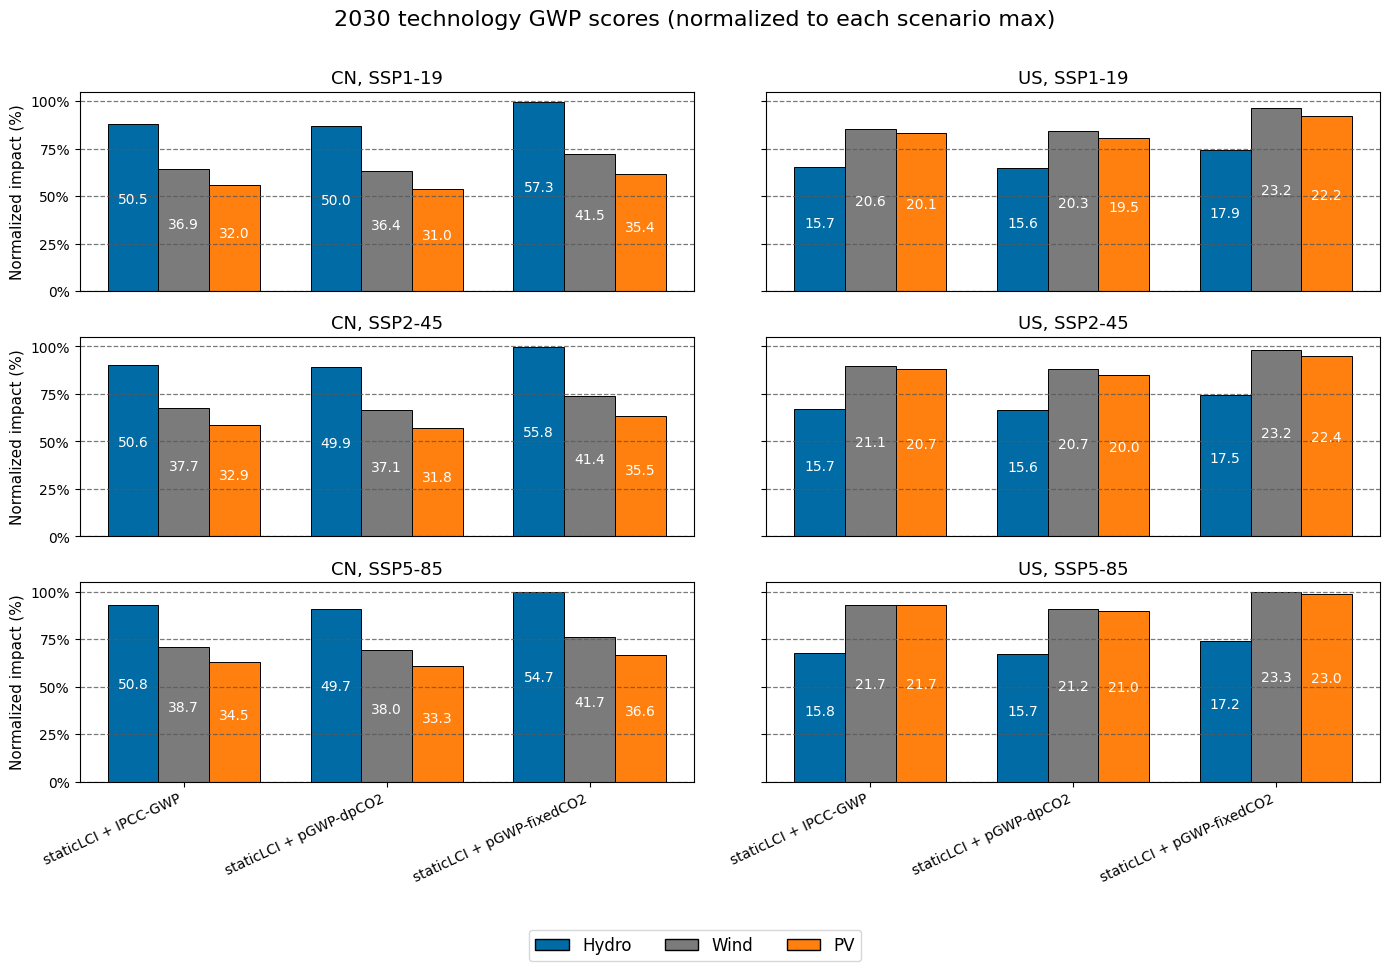

In [13]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    #"full dpLCI + pGWP-fixedCO2"
]

metric_labels = {m: m for m in metric_order}

tech_colors = {
    "Hydro": "#006BA4",
    "Wind":  "#7B7B7B",
    "PV":    "#FF800E"
}

#plot_bar_oneyear_only(df_full, 2050, metric_order, metric_labels, tech_colors)
plot_bar_oneyear_only(df_full, 2030, metric_order, metric_labels, tech_colors)


(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-19'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP1-19'}>],
        [<Axes: title={'center': 'CN, SSP2-45'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP2-45'}>],
        [<Axes: title={'center': 'CN, SSP5-85'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP5-85'}>]], dtype=object))

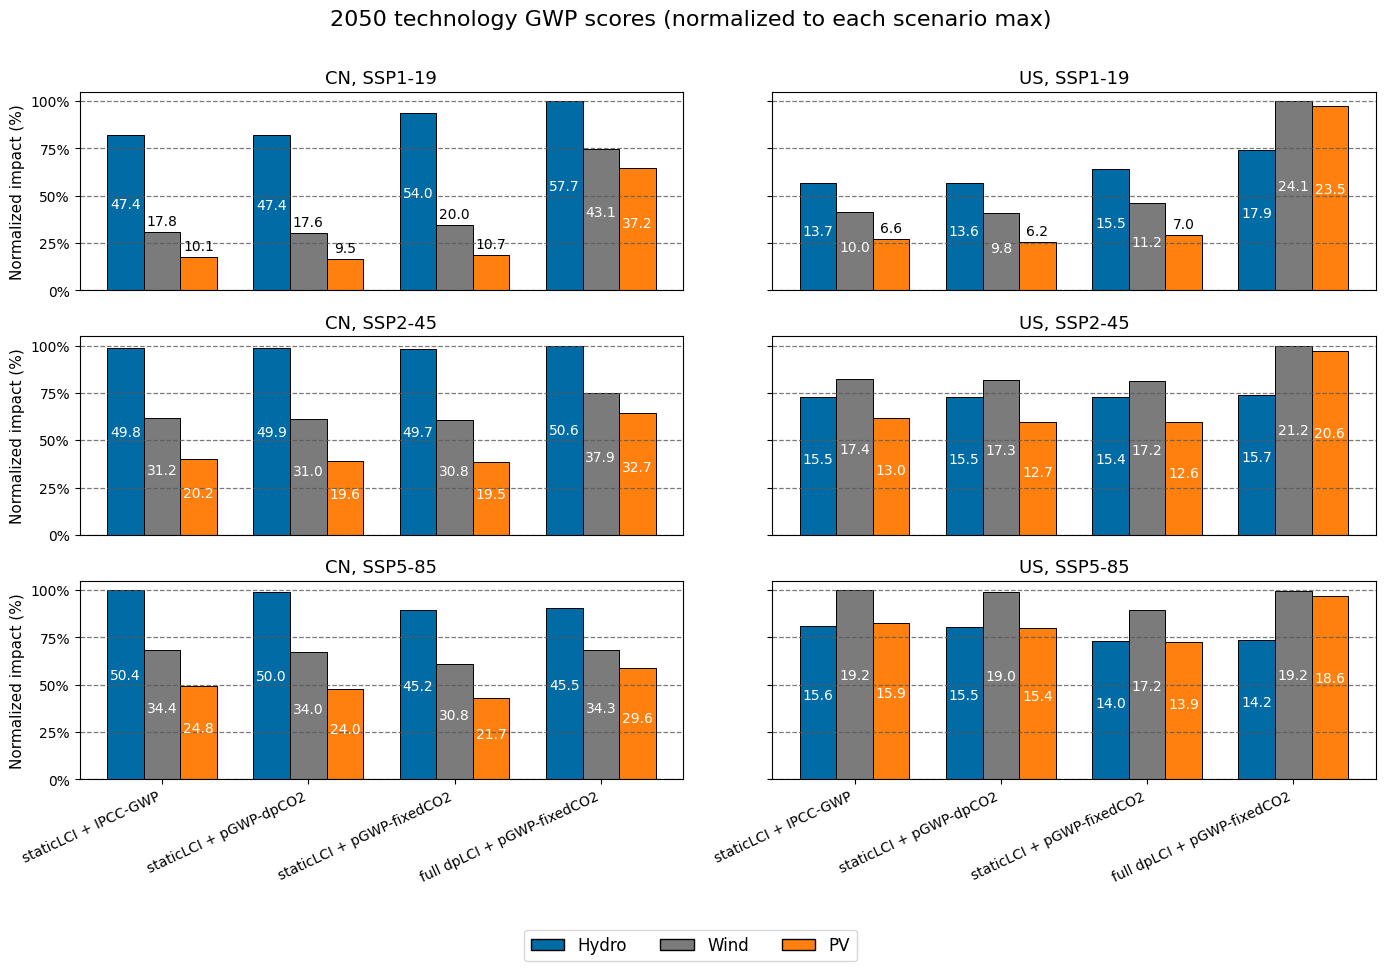

In [5]:
plot_bar_oneyear_only(df_full, 2050, metric_order, metric_labels, tech_colors)

#### plot one region, two years

In [16]:
metric_labels

{'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP',
 'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',
 'staticLCI + pGWP-fixedCO2': 'staticLCI + pGWP-fixedCO2'}

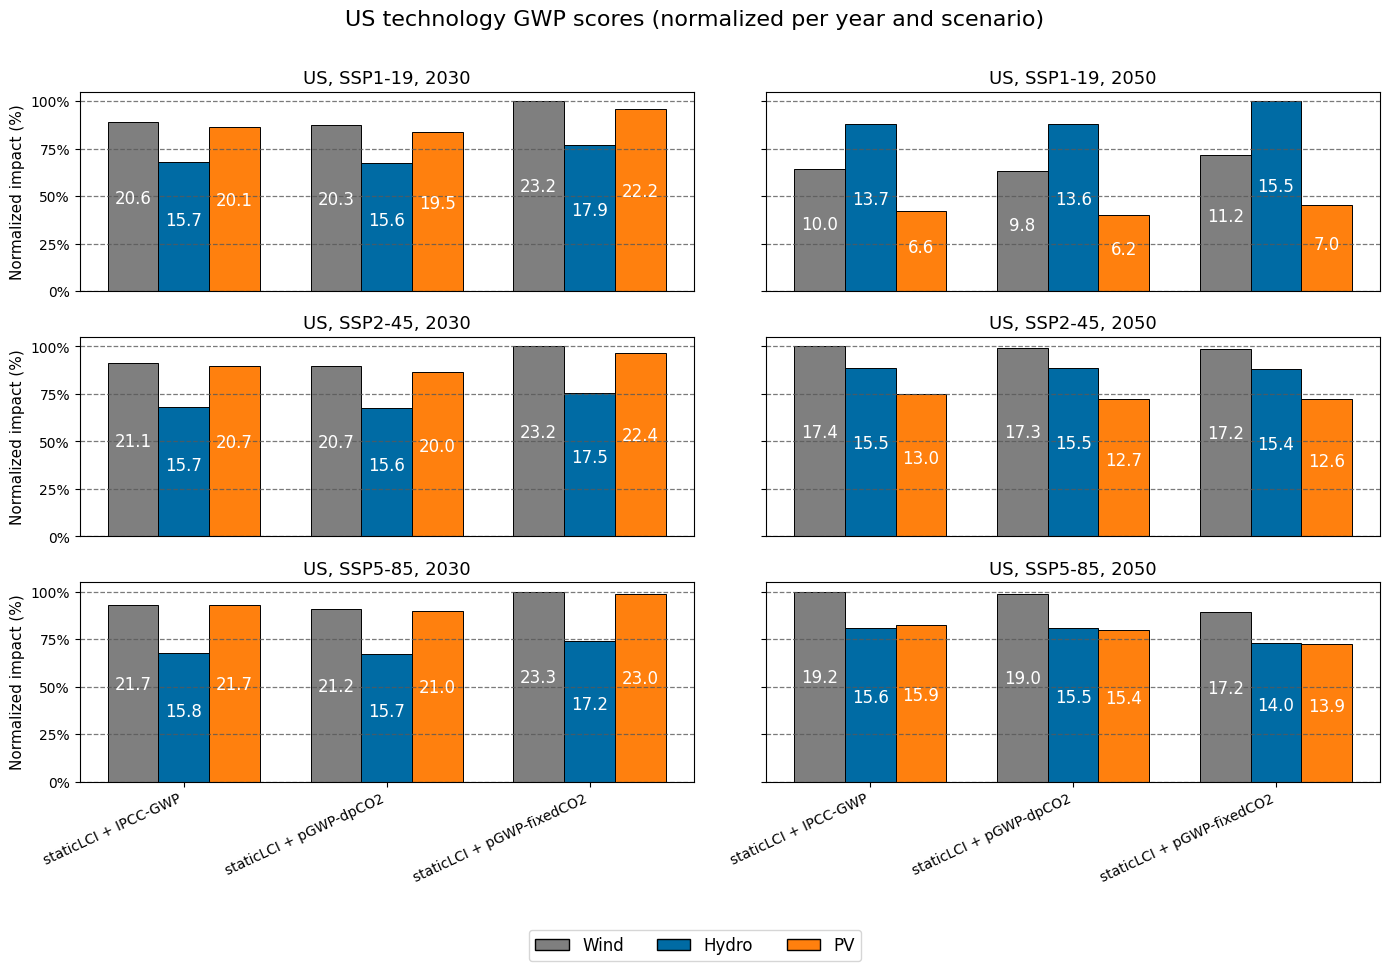

In [8]:
# let's filter out only three metric (caz we not suggest using pGWP100-dpCO2 anyways)
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    #"full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}


df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears(
    df_full=df_full_filt,
    years=(2030,2050),
    country="US",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
)


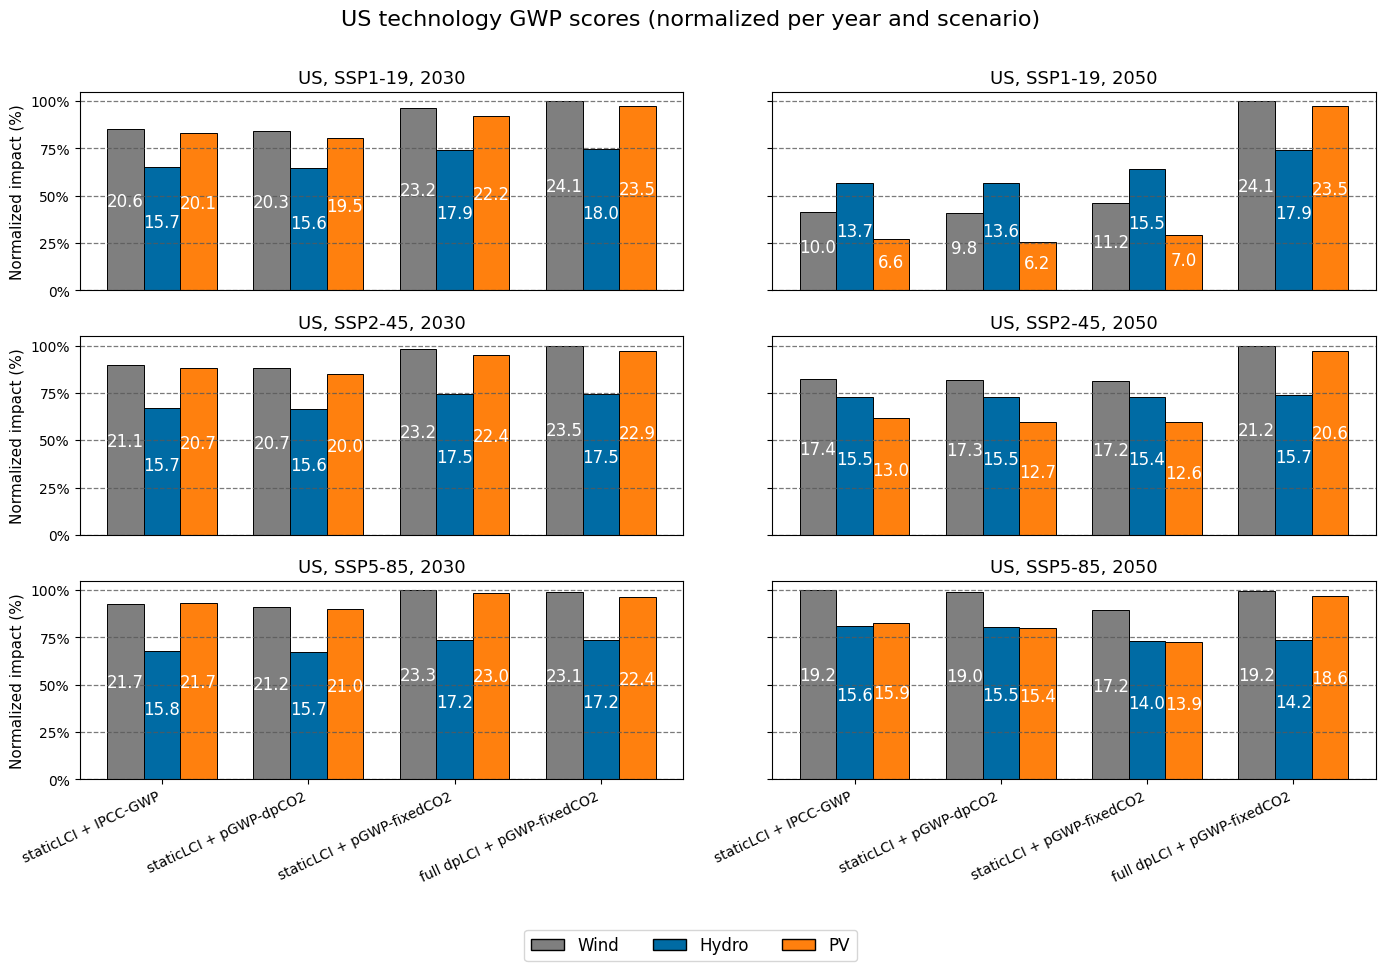

In [11]:
# let's filter out only three metric (caz we not suggest using pGWP100-dpCO2 anyways)

metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears(
    df_full=df_full_filt,
    years=(2030, 2050),
    country="US",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
)


### The apparent “improvement” in SSP5-2050 is a property of the relative metric rather than a change in the technology inventory. Under the fixed-CO₂ formulation, only the numerator is state-dependent while the CO₂ reference remains anchored to 2019; in high-forcing futures this can reduce the relative weighting of non-CO₂ gases compared with the static IPCC GWP100, yielding negative deviations. The dpCO₂ formulation largely avoids this artifact because both numerator and denominator evolve under the same scenario and year. This really supports our current discussion: relative metrics are sensitive to reference-gas choice and we DO NOT suggest using relative metric, thus, in step2 analysis, we continue with the full dpLCA (coupled full dpLCI with the dp-AGWP).
